In [ ]:
import sys
sys.path.insert(0, "../..")

from pilot.models        import DeepONet, build_deeponet
from pilot.data          import ODEIterableDataset, LatinHypercubeSampler
from pilot.physics       import harm_osc, ODEsolver

import numpy as np


import torch
from torch.utils.data import DataLoader

device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
import matplotlib.pyplot as plt 
import matplotlib.cm as cm


In [2]:
# Plot configuration

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"], 
})


cmap = cm.plasma # Color Scheme for oscillator plots 

color_gt    = cmap(0.7)  # Yellow/Orange
color_pred  = cmap(0.2)  # Purple
color_res   = cmap(0.45)  # Redish

In [3]:
# Initialize Harmonic Oscillator Object 
k = 2.0
c = 0.1
system = harm_osc([k, c])
solver = ODEsolver(system).solve

# Initialize Sampler Object 
sampler = LatinHypercubeSampler(

    dimensions = 2,
    lows       = [-1.0, -1.0],
    highs      = [1.0, 1.0]
    
)

In [4]:
dataset_size = 1001
batch_size   = 1
num_workers  = 2
t_final      = 10
t_span       = (0, t_final)

osc_dataset = ODEIterableDataset(size          = dataset_size,
                                 system_class  = system,
                                 sampler       = sampler,
                                 t_span        = t_span,
                                 full_solution = True)

osc_loader  = DataLoader(dataset     = osc_dataset,
                         batch_size  = batch_size,
                         num_workers = num_workers)


In [5]:
# Set Up DeepONet configuration 

DEEPONET_CONFIG = {
    
    "hidden_size" : 128,
    "depth"       : 6,
    "latent_size" : 50,
    "input_size_b": 2,
    "input_size_t": 1,
    "output_size" : 2,
    "activation"  : "tanh",

}

# 1. Initialize DeepONet network 

deeponet = build_deeponet(DEEPONET_CONFIG)

# 2. Load the saved weights into the model

state_dict = torch.load("../../weights/best_2d_osc.pth", map_location=device)
deeponet.load_state_dict(state_dict)
deeponet = deeponet.to(device)

# 3. Set to eval mode
deeponet.eval()
_ = 0

In [6]:
from src.benchmark import trajectory 

ts, sols, preds = [], [], []

for i in range(4):
    t, sol, pred = trajectory(deeponet, osc_loader, device)
    ts.append(t)
    sols.append(sol)
    preds.append(pred)

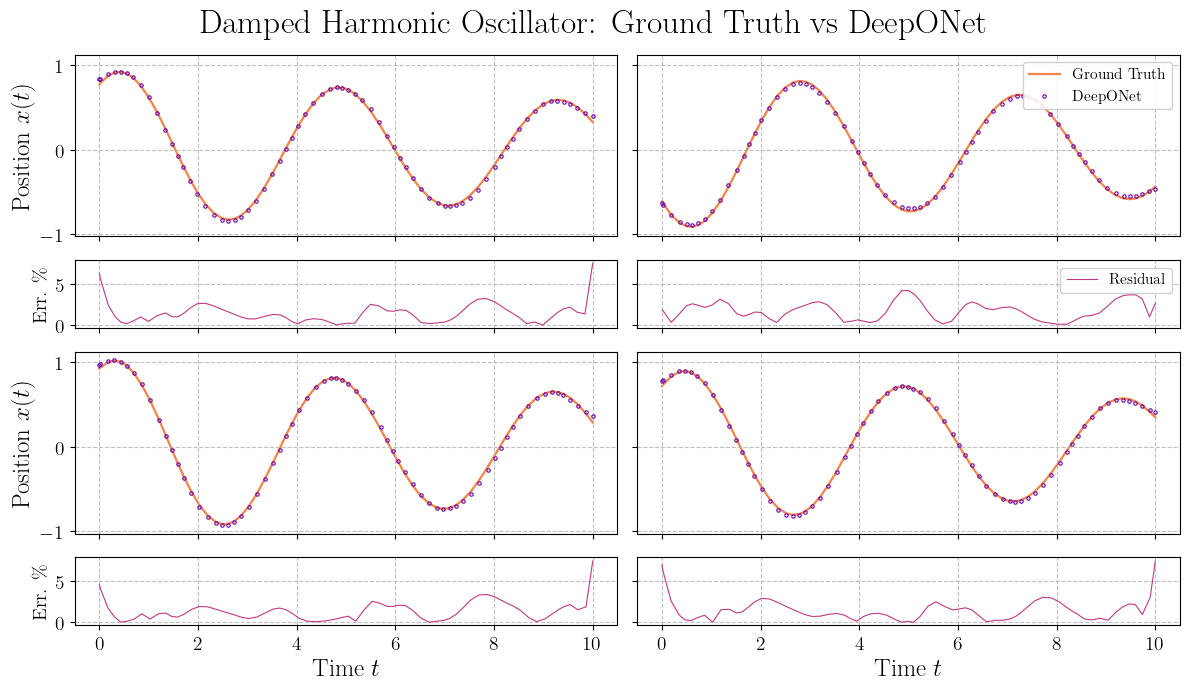

In [7]:
fig, axs = plt.subplots(4, 2, figsize=(12, 7),
                        sharex=True,
                        sharey=False,
                        gridspec_kw={"height_ratios": [4, 1.5, 4, 1.5]})

# Residuals need to share y axis
for ax in axs[::2, :].flatten()[1:]:
    ax.sharey(axs[0, 0])

# Share residual axes together
for ax in axs[1::2, :].flatten()[1:]:
    ax.sharey(axs[1, 0])


for i in range(4):

    row  = (i // 2) * 2 # This is 0 for i = 0, 1 and 2 for i = 2, 3
    col  = i % 2        # This is either 0, 1

    # Separate main plots from residuals 
    ax_main  = axs[row,     col]
    ax_res   = axs[row + 1, col] # sum one to be plotting in residuals

    # Main Plots
    ax_main.plot(ts[i], 
                sols[i][0],     
                color  = color_gt,   
                lw     = 1.6, 
                label  = "Ground Truth",
                zorder = 1)
    
    ax_main.scatter(ts[i], 
                preds[i][:, 0], 
                facecolors = (0, 0, 0, 0), 
                edgecolors = color_pred,
                lw         = 0.8, 
                label      = "DeepONet",
                s          = 6,
                zorder     = 2)
    
    ax_main.grid(linestyle="--", alpha=0.8)
    ax_main.tick_params(axis='both', labelsize=14)


    # Residual Plots
    amplitude = np.max(np.abs(sols[i][0]))
    residual  = np.abs((sols[i][0] - preds[i][:, 0])) / amplitude * 100
    ax_res.plot(ts[i], 
                residual, 
                color     = color_res, 
                lw        = 0.8, 
                label     = "Residual")
    
    ax_res.grid(linestyle="--", alpha=0.8)
    ax_res.tick_params(axis='both', labelsize=14)



axs[1, 1].legend(fontsize=11, framealpha=0.9,  loc="upper right")    
axs[0, 1].legend(fontsize=11, framealpha=0.9, loc="upper right")

for ax in axs[-1, :]:
    ax.set_xlabel("Time $t$", fontsize=18, color="black")
for ax in axs[::2, 0]:                  # main rows, left column
    ax.set_ylabel("Position $x(t)$", fontsize=18, color="black")
for ax in axs[1::2, 0]:                 # residual rows, left column
    ax.set_ylabel(r"Err. $\%$", fontsize=14, color="black")

# Hide y tick labels on right column
for ax in axs[:, 1]:
    ax.tick_params(labelleft=False)

fig.suptitle("Damped Harmonic Oscillator: Ground Truth vs DeepONet", fontsize=24, color="black")
plt.tight_layout()
# plt.savefig("oscillator_prediction.png", dpi=200, bbox_inches="tight")
plt.show()


In [8]:
# Set the full solution of the dataset back to false 

osc_dataset.full_solution = False

osc_loader  = DataLoader(dataset     = osc_dataset,
                         batch_size  = batch_size,
                         num_workers = num_workers)

In [ ]:
from src.benchmark import trajectory 


ts, sols, preds = [], [], []


for i in range(1000):
    t, sol, pred = trajectory(deeponet, osc_loader, device)
    ts.append(t)
    sols.append(sol)
    preds.append(pred)

In [10]:
preds_arr = np.array(preds)[:, 0] 
sols_arr  = np.array(sols)         

scale = np.abs(sols_arr).max() - np.abs(sols_arr).min()

percentage_error = np.mean(np.abs(preds_arr - sols_arr) / scale) * 100
print(f"NMAE: {percentage_error:.2f}%")

NMAE: 0.89%


In [11]:
from src.benchmark import timing_data

num_boxes   = 10
num_samples = 1000

nn_timing, solver_timing = timing_data(model       = deeponet, 
                                       ODEsolver   = solver, 
                                       sampler     = sampler,
                                       t_final     = t_final, 
                                       num_samples = num_samples,
                                       num_boxes   = num_boxes, 
                                       method      = "RK45",
                                       device      = device)


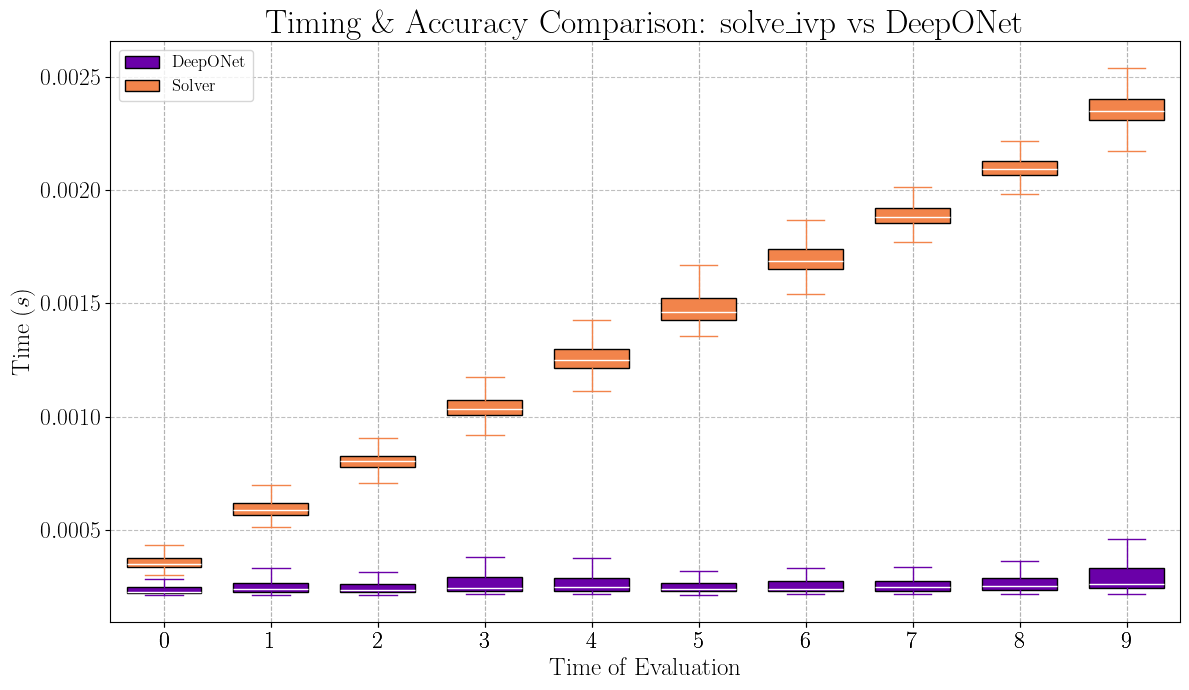

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))
cmap = cm.plasma

ax.boxplot(nn_timing, 
           positions    = np.arange(num_boxes),
           widths       = 0.70, 
           patch_artist = True,
           showfliers   = False, 
           boxprops     = dict(facecolor=color_pred, color="black"),
           medianprops  = dict(color="white"),
           whiskerprops = dict(color=color_pred),
           capprops     = dict(color=color_pred),
           label        = "DeepONet")

ax.boxplot(solver_timing,
           positions    = np.arange(num_boxes),
           widths       = 0.70,
           patch_artist = True,
           showfliers   = False,
           boxprops     = dict(facecolor=color_gt, color="black"),
           medianprops  = dict(color="white"),
           whiskerprops = dict(color=color_gt),
           capprops     = dict(color=color_gt),
           label        = "Solver")
                

ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel(r"Time of Evaluation",           fontsize=18, color="black")
ax.set_ylabel(r"Time ($s$)",                   fontsize=18, color="black")
ax.set_title(r"Timing \& Accuracy Comparison: solve\_ivp vs DeepONet", fontsize=24, color="black")
ax.legend(fontsize=14)
ax.grid(linestyle="--", alpha=0.8)
ax.legend(fontsize=12)
ax.tick_params(axis="both", labelsize=17)

plt.tight_layout()
plt.savefig("timing_comparison_osc.png", dpi=200, bbox_inches="tight")
plt.show()

In [13]:
from src.benchmark import semigroup_data

loss_fn     = torch.nn.MSELoss()
num_samples = 1000
num_boxes   = 20

loss_direct, loss_2step, loss_3step, sol_norms = semigroup_data(model       = deeponet, 
                                                                ODEsolver   = solver, 
                                                                sampler     = sampler,
                                                                loss_fn     = loss_fn,
                                                                t_final     = t_final, 
                                                                num_samples = num_samples, 
                                                                num_boxes   = num_boxes, 
                                                                out_mask    = [0, 1],
                                                                device      = device)

/home/enricp/miniconda3/envs/physics/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([2])) that is different to the input size (torch.Size([1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [14]:
loss_direct = np.array(loss_direct)  
loss_2step  = np.array(loss_2step)
loss_3step  = np.array(loss_3step)
sol_norms   = np.array(sol_norms)    

truth_means = np.mean(sol_norms, axis=1) 

# Normalize across 
pct_error_1 = (np.mean(loss_direct, axis=1) / truth_means) * 100
pct_error_2 = (np.mean(loss_2step,  axis=1) / truth_means) * 100
pct_error_3 = (np.mean(loss_3step,  axis=1) / truth_means) * 100

# Normalize for box plotting ([:, None] changes shape from (N,) to (N, 1))
pct_direct = (loss_direct / truth_means[:,None]) * 100 
pct_2step  = (loss_2step  / truth_means[:,None]) * 100
pct_3step  = (loss_3step  / truth_means[:,None]) * 100

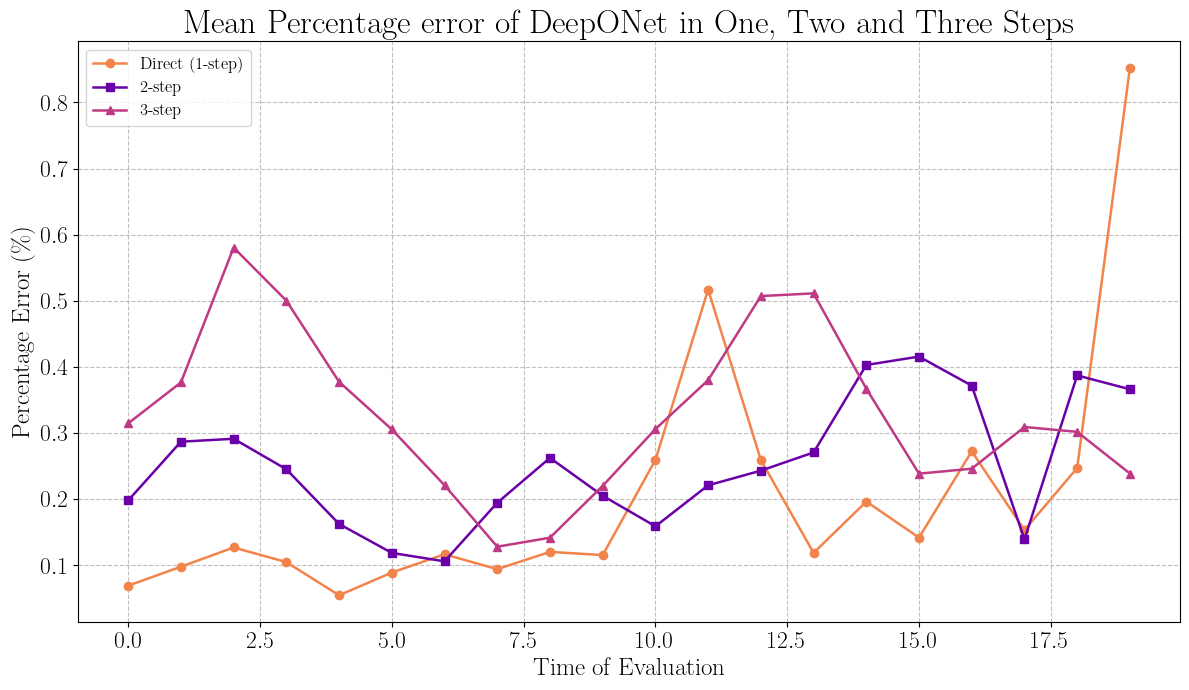

In [15]:
fig, ax = plt.subplots(figsize=(12, 7))

series = [
    (pct_error_1, 'o', 'Direct (1-step)', color_gt),
    (pct_error_2, 's', '2-step',          color_pred),
    (pct_error_3, '^', '3-step',          color_res),
]

x = np.arange(num_boxes)
for means, marker, label, color in series:
    ax.plot(x, means, marker=marker, label=label,
            color=color, linewidth=1.8, alpha=1.0)

ax.grid(linestyle='--', alpha=0.8)
ax.legend(fontsize=12)
ax.set_xlabel(r"Time of Evaluation",                    fontsize=18, color="black")
ax.set_ylabel(r"Percentage Error (\%)",                 fontsize=18, color="black")
ax.set_title(r"Mean Percentage error of DeepONet in One, Two and Three Steps", fontsize=24, color="black")
ax.tick_params(axis='both', labelsize=17) 

plt.tight_layout()
plt.savefig("mean_loss_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

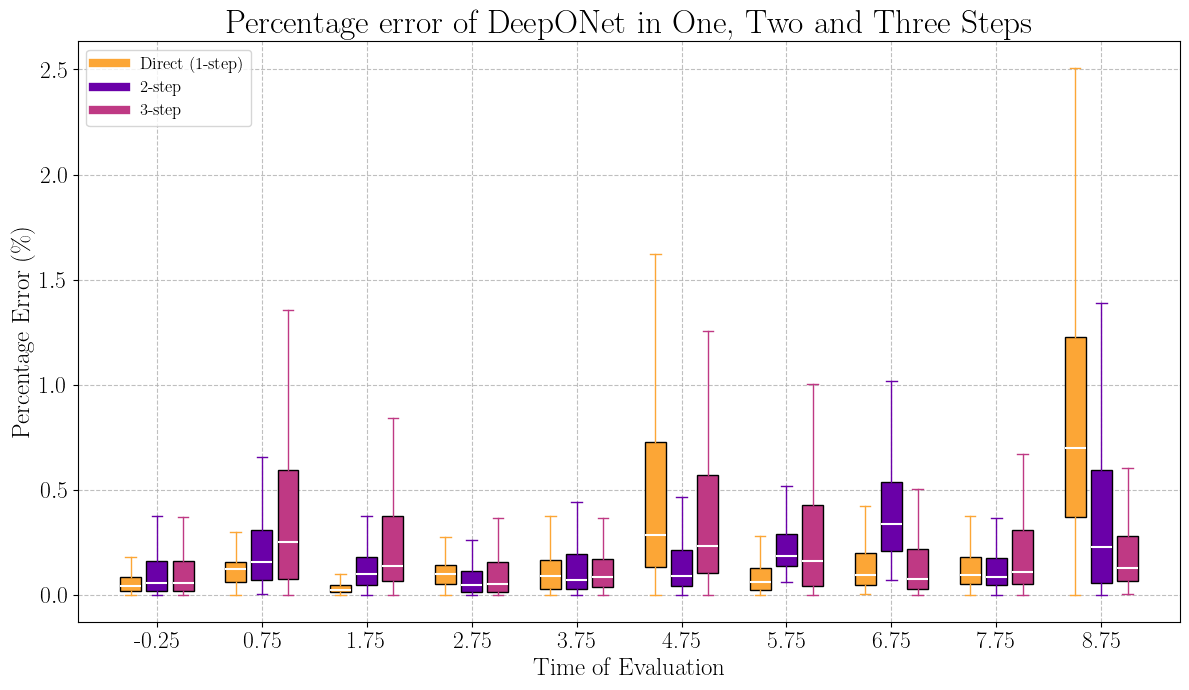

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))

cmap = cm.plasma
color_gt   = cmap(0.8)
color_pred = cmap(0.2)
color_res  = cmap(0.45)

n = 10
idx = np.round(np.linspace(0, len(pct_direct) - 1, n)).astype(int)

datasets = [
    [pct_direct[i] for i in idx],
    [pct_2step[i]  for i in idx],
    [pct_3step[i]  for i in idx],
]

labels   = ['Direct (1-step)', '2-step', '3-step']
colors   = [color_gt, color_pred, color_res]
offsets  = [-0.25, 0.0, 0.25]

for data, offset, color, label in zip(datasets, offsets, colors, labels):
    bp = ax.boxplot(
        data,
        positions    = np.arange(n) + offset,
        widths       = 0.2,
        patch_artist = True,
        showfliers   = False,
        medianprops  = dict(color="white", linewidth=1.5),
    )
    
    for box in bp['boxes']:
        box.set_facecolor(color)
    
    for element in ['whiskers', 'caps']:
        for line in bp[element]:
            line.set_color(color)
    
    ax.plot([], [], color=color, linewidth=6, label=label)

ax.set_xticks(np.arange(n))
ax.grid(linestyle='--', alpha=0.8)
ax.legend(fontsize=12)
ax.set_xlabel("Time of Evaluation", fontsize=18, color="black")
ax.set_ylabel(r"Percentage Error (\%)",        fontsize=18, color="black")
ax.set_title(r"Percentage error of DeepONet in One, Two and Three Steps", fontsize=24, color="black")
ax.tick_params(axis='both', labelsize=17) 
plt.tight_layout()
plt.savefig("boxplot_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import wandb

api = wandb.Api()
sweep = api.sweep("nikpursals/PINNS-testing/89oh0zw3")
runs = sweep.runs

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/enricp/.netrc.


In [18]:
run_data = []
for run in runs:
    history = run.history(keys=["val_loss"], pandas=False)
    val_loss = [row["val_loss"] for row in history if "val_loss" in row]
    run_data.append((val_loss, val_loss[-1]))


In [19]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})


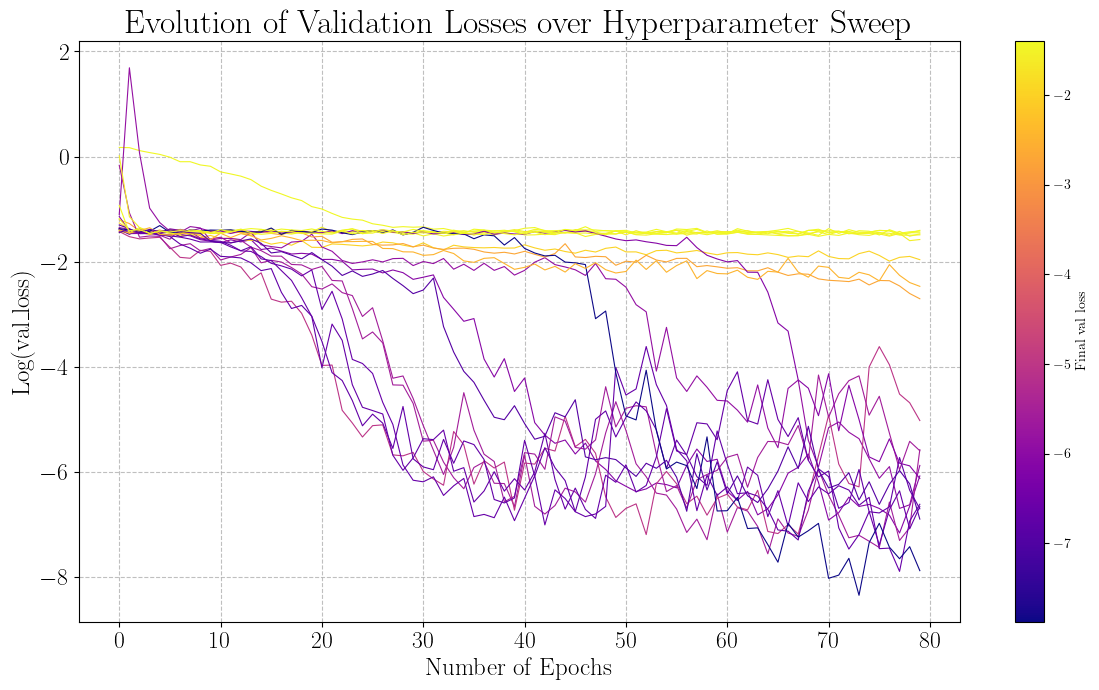

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))
cmap = cm.plasma

finals = [run[1] for run in run_data]
vmin, vmax = min(finals), max(finals)
norm = plt.Normalize(vmin, vmax)


for run in run_data:
    ax.plot(run[0], color=cmap(norm(run[1])), linewidth=0.8, alpha=1.0)


sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Final val loss")

ax.grid(linestyle="--", alpha=0.8)
ax.set_xlabel("Number of Epochs", fontsize=18, color="black")
ax.set_ylabel("Log(val_loss)", fontsize=18,  color="black")
ax.set_title("Evolution of Validation Losses over Hyperparameter Sweep", fontsize=24,  color="black")
ax.tick_params(axis='both', labelsize=17) 


plt.tight_layout()
# plt.savefig("val_loss_2d_osc.png", dpi=200, bbox_inches="tight")
plt.show()